In [81]:
# !pip install xgboost joblib
# !pip install matplotlib
# !pip install pandas
# !pip install numpy
# !pip install scikit-learn
# !pip install tensorflow
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import joblib

In [82]:
# Configuration for your building data
DATA_FOLDER = 'files_from_influx_PredictionAlg'

# CSV file paths
ENERGY_FILE = f'{DATA_FOLDER}/Cooling_Heating_Electricity_w_Shading.csv'
TEMPERATURE_FILE = f'{DATA_FOLDER}/Temperatures_w_Shading.csv'
DNI_FILE = f'{DATA_FOLDER}/DNI_w_Shading.csv'
SHADING_FILE = f'{DATA_FOLDER}/Shading_actions.csv'

# Energy conversion factors (adjust these for your building if needed)
PE_GAS = 1.00       # Primary energy factor for gas
PE_ELEC = 2.17      # Primary energy factor for electricity
COP_H = 0.98        # Coefficient of Performance for heating
EER_C = 5.4         # Energy Efficiency Ratio for cooling

In [83]:
class PredictionModel():
    """Two-stage cooling model with richer temporal features and tuned ON/OFF gating."""

    def __init__(self, cooling_threshold=1e-4, cooling_on_threshold=0.7):
        # store data splits
        self.X_train, self.y_train, self.timesteps_train = [], [], []
        self.X_test, self.y_test, self.timesteps_test = [], [], []
        self.dataset = None # store dataset

        # Configuration
        self.PE_GAS = PE_GAS
        self.PE_ELEC = PE_ELEC
        self.COP_H = COP_H
        self.EER_C = EER_C

        self.cooling_threshold = cooling_threshold  # threshold for detecting ON/OFF cooling
        self.cooling_on_threshold = cooling_on_threshold    # threshold for gating cooling magnitude predictions based on classifier probability

        # Models
        self.model_ele = None   # electricity regressor
        self.model_heat = None  # heating regressor
        self.model_cool_clf = None  # cooling ON/OFF classifier
        self.model_cool_reg = None  # cooling magnitude regressor (ON-only)

        # Calibration + diagnostics
        self.prob_calibrator = None # Platt-style calibrator for cooling ON probabilities
        self.threshold_search_results = None    # store threshold tuning results for analysis

    def load_from_csv(self, energy_file, temperature_file, dni_file, shading_file):
        """
        Load and merge data from CSV files exported from InfluxDB.
        Returns a cleaned DataFrame ready for feature engineering.
        """
        print("Loading CSV files...")

        # Load individual CSV files
        df_energy = pd.read_csv(energy_file)
        df_temp = pd.read_csv(temperature_file)
        df_dni = pd.read_csv(dni_file)
        df_shading = pd.read_csv(shading_file)

        # Rename 'Time' column to 'time' for consistency
        for df in [df_energy, df_temp, df_dni, df_shading]:
            df.rename(columns={'Time': 'time'}, inplace=True)

        # Convert time columns to datetime
        for df in [df_energy, df_temp, df_dni, df_shading]:
            df['time'] = pd.to_datetime(df['time'])

        # Start with energy data as base
        dataset = df_energy.copy()

        # Merge signals
        dataset = dataset.merge(df_temp, on='time', how='outer')
        dataset = dataset.merge(df_dni, on='time', how='outer')
        dataset = dataset.merge(df_shading, on='time', how='outer')

        # Sort by time
        dataset = dataset.sort_values('time').reset_index(drop=True)

        # Drop rows where energy columns are NaN BEFORE forward-filling
        energy_cols_raw = [
            c for c in dataset.columns
            if any(k in c for k in ('DistrictCooling', 'DistrictHeating', 'Electricity'))
        ]
        dataset = dataset.dropna(subset=energy_cols_raw)

        # Forward fill auxiliary signals only
        dataset = dataset.ffill()

        # Drop any remaining NaN values
        dataset = dataset.dropna()

        print(f"Loaded {len(dataset)} records")
        print(f"Date range: {dataset['time'].min()} to {dataset['time'].max()}")
        print(f"Columns: {list(dataset.columns)}")

        # Rename columns to match expected names
        column_mapping = {}
        for col in dataset.columns:
            if 'DistrictCooling' in col:
                column_mapping[col] = 'DistrictCooling'
            elif 'DistrictHeating' in col:
                column_mapping[col] = 'DistrictHeating'
            elif 'Electricity' in col and 'DistrictCooling' not in col and 'DistrictHeating' not in col:
                column_mapping[col] = 'Electricity'
            elif 'Tin_Flat2_Zona1' in col or ('Zona1' in col and 'Tin' in col):
                column_mapping[col] = 'Tair_z1'
            elif 'Tin_Flat2_Zona2' in col or ('Zona2' in col and 'Tin' in col):
                column_mapping[col] = 'Tair_z2'
            elif 'Tin_Flat2_Zona3' in col or ('Zona3' in col and 'Tin' in col):
                column_mapping[col] = 'Tair_z3'
            elif 'Tin_Flat2_Zona4' in col or ('Zona4' in col and 'Tin' in col):
                column_mapping[col] = 'Tair_z4'
            elif 'Tout' in col:
                column_mapping[col] = 'T_ext'
            elif 'DNI' in col:
                column_mapping[col] = 'DNI'
            elif 'A_Shade_Flat2_Z1_W2' in col:
                column_mapping[col] = 'Zona1_wall2_shade'
            elif 'A_Shade_Flat2_Z1_W8' in col:
                column_mapping[col] = 'Zona1_wall8_shade'
            elif 'A_Shade_Flat2_Z1_W9' in col:
                column_mapping[col] = 'Zona1_wall9_shade'
            elif 'A_Shade_Flat2_Z2_W2' in col:
                column_mapping[col] = 'Zona2_wall2_shade'
            elif 'A_Shade_Flat2_Z2_W3' in col:
                column_mapping[col] = 'Zona2_wall3_shade'
            elif 'A_Shade_Flat2_Z4_W2' in col:
                column_mapping[col] = 'Zona4_wall2_shade'

        dataset.rename(columns=column_mapping, inplace=True)

        # Convert energy data from Joules to kWh
        energy_fields = ['Electricity', 'DistrictHeating', 'DistrictCooling']
        for field in energy_fields:
            if field in dataset.columns:
                dataset[field] = dataset[field] / 3600000

        print(f"\nEnergy values (kWh):")
        for field in energy_fields:
            if field in dataset.columns:
                print(f"  {field}: {dataset[field].iloc[10:15].values}")

        print(f"\nColumn mapping complete. Final columns: {list(dataset.columns)}")
        dataset.to_csv('Prediction_Algorithm_dataset.csv', index=False)
        return dataset

    def split(self, dataset, train_ratio=0.8):
        """Feature engineering with stronger temporal context for cooling."""
        print("\nFeature engineering...")

        ds = dataset.copy()
        self.dataset = ds.copy()

        # Thermal aggregation
        tair_cols = ['Tair_z1', 'Tair_z2', 'Tair_z3', 'Tair_z4']
        ds['Tair_mean'] = ds[tair_cols].mean(axis=1)    # mean indoor air temperature
        ds['DeltaT'] = ds['Tair_mean'] - ds['T_ext']    # difference between indoor and outdoor temperature

        # Time features
        ds['hour'] = ds['time'].dt.hour
        ds['hour_sin'] = np.sin(2 * np.pi * ds['hour'] / 24)    # capture daily cycles
        ds['hour_cos'] = np.cos(2 * np.pi * ds['hour'] / 24)
        ds['dayofyear'] = ds['time'].dt.dayofyear
        ds['doy_sin'] = np.sin(2 * np.pi * ds['dayofyear'] / 365)   # capture seasonal cycles
        ds['doy_cos'] = np.cos(2 * np.pi * ds['dayofyear'] / 365)

        # Interaction features to improve cooling peaks
        ds['DNI_x_DeltaT'] = ds['DNI'] * ds['DeltaT']
        ds['DNI_x_Text'] = ds['DNI'] * ds['T_ext']

        # Extended lag features
        lag_steps = [1, 6, 12, 24]
        for w in lag_steps:
            ds[f'Electricity_lag{w}'] = ds['Electricity'].shift(w)  # at timestep t, value from t-w
            ds[f'Heating_lag{w}'] = ds['DistrictHeating'].shift(w)  
            ds[f'Cooling_lag{w}'] = ds['DistrictCooling'].shift(w)

            # Rolling features
            ds[f'Cooling_roll_mean_{w}'] = ds['DistrictCooling'].rolling(w).mean() # mean over past w timesteps
            ds[f'Heating_roll_mean_{w}'] = ds['DistrictHeating'].rolling(w).mean()
        
            # Consecutive recent ON indicator
            cooling_on = (ds['DistrictCooling'] > self.cooling_threshold).astype(int)   # binary indicator of cooling ON at each timestep
            ds[f'Cooling_on_recent_{w}'] = cooling_on.rolling(w).sum() # count of cooling ON in past w timesteps (0-w)

        ds = ds.dropna().reset_index(drop=True)

        X_cols = [ 
            'T_ext', 'DNI', 'Tair_mean', 'DeltaT',
            'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos',
            'DNI_x_DeltaT', 'DNI_x_Text',
            *[f'Electricity_lag{w}' for w in lag_steps],
            *[f'Heating_lag{w}' for w in lag_steps],
            *[f'Cooling_lag{w}' for w in lag_steps],
            *[f'Cooling_roll_mean_{w}' for w in lag_steps],
            *[f'Cooling_on_recent_{w}' for w in lag_steps],
            *[f'Heating_roll_mean_{w}' for w in lag_steps]
        ]   # final feature set for modeling

        X = ds[X_cols]  # features dataset
        y = ds[['Electricity', 'DistrictHeating', 'DistrictCooling']]   # target dataset
        timesteps = ds['time']

        split_point = int(len(X) * train_ratio) # split index for chronological train/test split
        self.X_train, self.y_train, self.timesteps_train = X.iloc[:split_point], y.iloc[:split_point], timesteps.iloc[:split_point]
        self.X_test, self.y_test, self.timesteps_test = X.iloc[split_point:], y.iloc[split_point:], timesteps.iloc[split_point:]

        print(f"Training set: {len(self.X_train)} samples")
        print(f"Testing set: {len(self.X_test)} samples")
        print(f"Features ({len(X_cols)}): {X_cols}")

        # store in csv train and test sets
        self.X_train.to_csv('X_train.csv', index=False)
        self.y_train.to_csv('y_train.csv', index=False)
        self.X_test.to_csv('X_test.csv', index=False)
        self.y_test.to_csv('y_test.csv', index=False)

    def compute_total_primary_energy(self, df):
        """Compute Total Primary Energy from individual energy components."""
        df = df.copy()
        df['Total_Primary_Energy'] = (
            (df['DistrictHeating'] / self.COP_H * self.PE_GAS) +
            (df['DistrictCooling'] / self.EER_C * self.PE_ELEC) +
            (df['Electricity'] * self.PE_ELEC)
        )
        return df

    def _tune_cooling_threshold(self, y_true_cool, p_on, pred_cool_mag):
        """Tune hard-gating threshold on validation set."""
        candidates = np.round(np.arange(0.30, 0.91, 0.05), 2)   # candidate thresholds from 0.30 to 0.90 in steps of 0.05
        best_thr = self.cooling_on_threshold    # initialize best threshold with default value
        best_r2 = -np.inf
        rows = []

        for thr in candidates:
            y_pred = np.where(p_on >= thr, pred_cool_mag, 0.0)  # where calibrated probability exceeds threshold, use predicted cooling magnitude; otherwise predict 0
            r2 = r2_score(y_true_cool, y_pred)  # compute R² score for this threshold to evaluate how well the hard-gated predictions match the true cooling values on the validation set
            mse = mean_squared_error(y_true_cool, y_pred)   # compute MSE for additional diagnostic information
            rows.append((thr, r2, mse, p_on))
            if r2 > best_r2:    # if this threshold gives better R² than previous best, update best threshold and best R²
                best_r2 = r2
                best_thr = float(thr)

        # store threshold tuning results in a DataFrame for analysis and reporting
        self.threshold_search_results = pd.DataFrame(rows, columns=['threshold', 'r2', 'mse', 'probabilities']).sort_values('threshold').reset_index(drop=True)
        # save as csv
        self.threshold_search_results.to_csv('threshold_search_results.csv', index=False)
        self.cooling_on_threshold = best_thr
        print(f"Selected cooling_on_threshold = {self.cooling_on_threshold:.2f} (validation R² = {best_r2:.4f})")

    def train(self):
        """Train separate models per target, calibrate cooling probabilities, and tune gating threshold."""
        print("\nTraining 2-stage XGBoost models...")

        # parameters for all regressors
        base_reg_params = dict(
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            objective='reg:squarederror',
            random_state=42
        )

        # Electricity model
        self.model_ele = xgb.XGBRegressor(**base_reg_params)
        self.model_ele.fit(self.X_train, self.y_train['Electricity'])

        # District Heating model
        self.model_heat = xgb.XGBRegressor(**base_reg_params)
        self.model_heat.fit(self.X_train, self.y_train['DistrictHeating'])

        # Build inner chronological validation split for cooling tuning
        n = len(self.X_train)
        val_start = max(int(n * 0.8), 1)    # ensure at least 1 sample in validation set, 20% split for validation
        X_fit, X_val = self.X_train.iloc[:val_start], self.X_train.iloc[val_start:]
        y_fit, y_val = self.y_train.iloc[:val_start], self.y_train.iloc[val_start:]

        # Fallback when dataset is too small
        if len(X_val) < 20:
            X_fit, X_val = self.X_train, self.X_train   # use all data for fitting if validation set is too small
            y_fit, y_val = self.y_train, self.y_train

        # Cooling classifier
        y_cool_fit = y_fit['DistrictCooling'].values    # raw cooling values for fitting classifier
        y_on_fit = (y_cool_fit > self.cooling_threshold).astype(int)    # binary ON/OFF labels for classifier
        pos = int(y_on_fit.sum())   # count of ON samples in fitting set
        neg = int(len(y_on_fit) - pos)  # count of OFF samples in fitting set
        scale_pos_weight = neg / max(pos, 1)    # handle class imbalance by weighting ON samples more if they are rarer

        # parameters for cooling classifier with class imbalance handling
        clf_params = dict(
            n_estimators=700,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            scale_pos_weight=scale_pos_weight
        )

        # District Cooling ON/OFF classifier
        self.model_cool_clf = xgb.XGBClassifier(**clf_params)
        self.model_cool_clf.fit(X_fit, y_on_fit)    # predict if cooling is ON or OFF based on features

        # Cooling magnitude regressor (ON-only) with peak-aware weights
        reg_idx = y_on_fit == 1 # extract indices in which cooling is ON
        if reg_idx.sum() < 20:
            print("Warning: too few cooling ON samples. Falling back to all samples for cooling regressor.")
            reg_idx = np.ones_like(y_on_fit, dtype=bool)    # use all samples if not enough ON samples

        y_cool_fit_sel = y_cool_fit[reg_idx]    # cooling values for regression (only ON samples)
        y_cool_log = np.log1p(y_cool_fit_sel)   # log-transform to stabilize variance and handle skewness
        sample_w = 1.0 + 2.0 * (y_cool_fit_sel / (np.percentile(y_cool_fit_sel, 90) + 1e-8))    # weight samples by their cooling magnitude to focus on peaks, normalized by 90th percentile to avoid extreme weights
        sample_w = np.clip(sample_w, 1.0, 3.0)  # cap weights to prevent instability from outliers

        # District Cooling magnitude regressor (trained only on ON samples, with log-transform and peak-aware weighting)
        self.model_cool_reg = xgb.XGBRegressor(**base_reg_params)
        self.model_cool_reg.fit(X_fit.loc[reg_idx], y_cool_log, sample_weight=sample_w)

        # Validation-based calibration + threshold tuning
        p_val = self.model_cool_clf.predict_proba(X_val)[:, 1]  # predicted probabilities of cooling being ON from the classifier on validation set

        pred_cool_log_val = self.model_cool_reg.predict(X_val)  # predicted log cooling magnitudes from the regressor on validation set
        pred_cool_mag_val = np.clip(np.expm1(pred_cool_log_val), 0, None)   # convert back to original scale and ensure non-negativity
        self._tune_cooling_threshold(y_val['DistrictCooling'].values, p_val, pred_cool_mag_val)  # tune the hard-gating threshold for cooling magnitude predictions based on validation set performance

        print("2-stage model training complete!")
        print(f"Cooling ON samples (fit): {pos}/{len(y_on_fit)} ({100.0 * pos / len(y_on_fit):.2f}%)")

    def get_test_predictions(self):
        """Hard-gated 2-stage cooling prediction with calibrated probabilities."""
        needed = [self.model_ele, self.model_heat, self.model_cool_clf, self.model_cool_reg]
        if any(m is None for m in needed):  # check if all models are trained before making predictions
            raise ValueError("2-stage models are not trained. Please run train() first.")
        if self.X_test.empty or self.y_test.empty:
            raise ValueError("Test data is not available. Please run split() first.")

        pred_ele = self.model_ele.predict(self.X_test)  # predict electricity using the electricity regressor
        pred_heat = self.model_heat.predict(self.X_test)    # predict heating using the heating regressor

        p_on_raw = self.model_cool_clf.predict_proba(self.X_test)[:, 1] # raw predicted probabilities of cooling being ON from the classifier on test set
        p_on = p_on_raw  # use raw probabilities for prediction
        pred_cool_log = self.model_cool_reg.predict(self.X_test)    # predicted log cooling magnitudes from the regressor on test set
        pred_cool_mag = np.clip(np.expm1(pred_cool_log), 0, None)   # convert back to original scale and ensure non-negativity

        pred_cool = np.where(p_on >= self.cooling_on_threshold, pred_cool_mag, 0.0) # hard-gate cooling predictions based on whether calibrated probability exceeds the tuned threshold; if above threshold, use predicted magnitude; otherwise predict 0
        return np.column_stack([pred_ele, pred_heat, pred_cool])

    def test_and_evaluate(self):
        """Evaluate model performance with extra diagnostics for cooling."""
        try:
            predictions = self.get_test_predictions()
        except ValueError as e:
            print(f"Error: {e}")
            return

        print("\n=== 2-Stage Model Evaluation Results ===\n")
        targets = ['Electricity', 'DistrictHeating', 'DistrictCooling']
        df_pred = pd.DataFrame(predictions, columns=targets, index=self.y_test.index)
        df_actual = self.y_test.copy()

        df_pred = self.compute_total_primary_energy(df_pred)    # compute Total Primary Energy for predictions
        df_actual = self.compute_total_primary_energy(df_actual)    # compute Total Primary Energy for actual values

        all_targets = targets + ['Total_Primary_Energy']
        for target_name in all_targets:
            # compute NMSE (normalized by variance of actual values), MSE, and R² for each target to evaluate prediction performance, with special attention to cooling metrics
            nmse = mean_squared_error(df_actual[target_name], df_pred[target_name]) / (df_actual[target_name].var() + 1e-8)
            mse = mean_squared_error(df_actual[target_name], df_pred[target_name])
            r2 = r2_score(df_actual[target_name], df_pred[target_name])
            print(f"{target_name:25s} -> NMSE: {nmse:.8e}, MSE: {mse:.8e}, R²: {r2:.4f}")

        # ON-only cooling diagnostics
        cool_on_mask = df_actual['DistrictCooling'] > self.cooling_threshold    # mask for samples where cooling is actually ON in the test set to evaluate how well the model predicts cooling magnitudes during active cooling periods
        if cool_on_mask.sum() > 0:
            mse_on = mean_squared_error(
                df_actual.loc[cool_on_mask, 'DistrictCooling'],
                df_pred.loc[cool_on_mask, 'DistrictCooling']
            )
            r2_on = r2_score(
                df_actual.loc[cool_on_mask, 'DistrictCooling'],
                df_pred.loc[cool_on_mask, 'DistrictCooling']
            )
            print("\nCooling ON-only diagnostics:")
            print(f"Samples: {cool_on_mask.sum()} / {len(cool_on_mask)}")
            print(f"DistrictCooling (ON only) -> MSE: {mse_on:.8e}, R²: {r2_on:.4f}")

        if self.threshold_search_results is not None:
            print("\nThreshold tuning table (validation):")
            print(self.threshold_search_results.to_string(index=False))

    def save_model(self, filepath):
        """Save the 2-stage model bundle to disk."""
        needed = [self.model_ele, self.model_heat, self.model_cool_clf, self.model_cool_reg]
        if any(m is None for m in needed):
            print("Model is not trained. Cannot save.")
            return

        bundle = {
            'model_ele': self.model_ele,
            'model_heat': self.model_heat,
            'model_cool_clf': self.model_cool_clf,
            'model_cool_reg': self.model_cool_reg,
            'prob_calibrator': self.prob_calibrator,
            'cooling_threshold': self.cooling_threshold,
            'cooling_on_threshold': self.cooling_on_threshold,
            'threshold_search_results': self.threshold_search_results
        }

        try:
            joblib.dump(bundle, filepath)
            print(f"2-stage model bundle saved to: {filepath}")
        except Exception as e:
            print(f"Failed to save model: {e}")

    def load_model(self, filepath):
        """Load a saved 2-stage model bundle from disk."""
        try:
            bundle = joblib.load(filepath)
            self.model_ele = bundle['model_ele']
            self.model_heat = bundle['model_heat']
            self.model_cool_clf = bundle['model_cool_clf']
            self.model_cool_reg = bundle['model_cool_reg']
            self.prob_calibrator = bundle.get('prob_calibrator', None)
            self.cooling_threshold = bundle.get('cooling_threshold', self.cooling_threshold)
            self.cooling_on_threshold = bundle.get('cooling_on_threshold', self.cooling_on_threshold)
            self.threshold_search_results = bundle.get('threshold_search_results', None)
            print(f"2-stage model bundle loaded from: {filepath}")
        except FileNotFoundError:
            print(f"Model file not found: {filepath}")
        except Exception as e:
            print(f"Failed to load model: {e}")

    def plot_feature_importance(self):
        """Plot feature importance of the four internal models and identify useless features."""
        needed = [self.model_ele, self.model_heat, self.model_cool_clf, self.model_cool_reg]
        if any(m is None for m in needed):
            print("Models not trained.")
            return

        feature_names = self.X_train.columns.tolist()
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        axes = axes.flatten()

        models = [
            ('Electricity (Regressor)', self.model_ele),
            ('DistrictHeating (Regressor)', self.model_heat),
            ('DistrictCooling ON/OFF (Classifier)', self.model_cool_clf),
            ('DistrictCooling Magnitude (Regressor)', self.model_cool_reg),
        ]

        # Collect feature importance scores from all models
        importance_scores = {}
        for feature in feature_names:
            importance_scores[feature] = []

        for ax, (title, mdl) in zip(axes, models):
            booster = mdl.get_booster()
            booster.feature_names = feature_names

            # importance_threshold = 0.00001
            
            # Get importance scores for this model
            importance_dict = booster.get_score(importance_type='gain')
            for feature in feature_names:
                importance_scores[feature].append(importance_dict.get(feature, 0))
                # if importance_scores[feature][-1] < importance_threshold:
                #     print(f"Feature {feature} can be removed from model {title}")
            
            xgb.plot_importance(booster, importance_type='gain', ax=ax, show_values=False, title=title)

        plt.tight_layout()
        plt.show()

        # Analyze feature importance across all models
        print("\n=== Feature Importance Analysis ===\n")
        importance_df = pd.DataFrame(
            importance_scores,
            index=['Electricity', 'DistrictHeating', 'Cooling Classifier', 'Cooling Regressor']
        ).T
        
        importance_df['mean'] = importance_df.mean(axis=1)
        importance_df['max'] = importance_df.max(axis=1)
        importance_df['non_zero_count'] = (importance_df.iloc[:, :-2] > 0).sum(axis=1)
        importance_df = importance_df.sort_values('mean', ascending=False)
        
        print("Feature importance across all models:")
        print(importance_df)
      
        # Identify most important features
        top_n = 10
        print(f"\n✓ Top {top_n} most important features (by mean importance):")
        for idx, (feat, row) in enumerate(importance_df.head(top_n).iterrows(), 1):
            print(f"   {idx}. {feat:30s} -> mean: {row['mean']:.6f}, max: {row['max']:.6f}")

    def plot_scatter_error(self):
        """Plot predicted vs actual values with error coloring."""
        try:
            predictions = self.get_test_predictions()
        except ValueError as e:
            print(f"Error: {e}")
            return

        targets = ['Electricity', 'DistrictHeating', 'DistrictCooling']
        df_pred = pd.DataFrame(predictions, columns=targets, index=self.y_test.index)
        df_actual = self.y_test.copy()

        df_pred = self.compute_total_primary_energy(df_pred)
        df_actual = self.compute_total_primary_energy(df_actual)

        if len(df_actual) > 10000:
            sample_idx = df_actual.sample(10000).index
            df_actual = df_actual.loc[sample_idx]
            df_pred = df_pred.loc[sample_idx]

        all_targets = targets + ['Total_Primary_Energy']
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()

        for i, col in enumerate(all_targets):
            actual = df_actual[col]
            pred = df_pred[col]
            errors = np.abs(pred - actual)

            sc = axes[i].scatter(actual, pred, c=errors, cmap='coolwarm', s=20, alpha=0.7)
            fig.colorbar(sc, ax=axes[i], label='Abs Error')

            min_val = min(actual.min(), pred.min())
            max_val = max(actual.max(), pred.max())
            axes[i].plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1)

            axes[i].set_title(f"Actual vs Predicted: {col}")
            axes[i].set_xlabel('Actual')
            axes[i].set_ylabel('Predicted')
            axes[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_error_vs_actual(self):
        """Plot residual errors vs actual values."""
        try:
            predictions = self.get_test_predictions()
        except ValueError as e:
            print(f"Error: {e}")
            return

        targets = ['Electricity', 'DistrictHeating', 'DistrictCooling']
        df_pred = pd.DataFrame(predictions, columns=targets, index=self.y_test.index)
        df_actual = self.y_test.copy()

        df_pred = self.compute_total_primary_energy(df_pred)
        df_actual = self.compute_total_primary_energy(df_actual)

        if len(df_actual) > 10000:
            sample_idx = df_actual.sample(10000).index
            df_actual = df_actual.loc[sample_idx]
            df_pred = df_pred.loc[sample_idx]

        all_targets = targets + ['Total_Primary_Energy']
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()

        for i, col in enumerate(all_targets):
            actual = df_actual[col]
            residual = df_pred[col] - actual

            axes[i].scatter(actual, residual, s=15, alpha=0.6, color='tab:blue')
            axes[i].axhline(0, color='black', linewidth=1.5, linestyle='--')
            axes[i].set_title(f"Residuals: {col}")
            axes[i].set_xlabel('Actual Value')
            axes[i].set_ylabel('Error (Pred - Actual)')
            axes[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

print("PredictionModel with calibrated 2-stage cooling defined")

PredictionModel with calibrated 2-stage cooling defined


In [84]:
# Load data from CSV files
model = PredictionModel()
dataset = model.load_from_csv(ENERGY_FILE, TEMPERATURE_FILE, DNI_FILE, SHADING_FILE)

# Display dataset info
print(f"\nDataset shape: {dataset.shape}")
print(f"\nFirst few rows:")
print(dataset.head())

Loading CSV files...
Loaded 1429 records
Date range: 2026-01-04 01:00:00 to 2026-12-27 01:00:00
Columns: ['time', 'simulation_observations.mean { name: DistrictCooling }', 'simulation_observations.mean { name: DistrictHeating }', 'simulation_observations.mean { name: Electricity }', 'simulation_observations.mean { name: Tin_Flat2_Zona1 }', 'simulation_observations.mean { name: Tin_Flat2_Zona2 }', 'simulation_observations.mean { name: Tin_Flat2_Zona3 }', 'simulation_observations.mean { name: Tin_Flat2_Zona4 }', 'simulation_observations.mean { name: Tout }', 'simulation_observations.mean { name: DNI }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W2 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W8 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W9 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z2_W2 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z2_W3 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z4_W2 }', 'simulation_actions.mean { name: A_Shade_Stair_Z1

In [85]:
# Prepare features and split data (70% train, 30% test)
model.split(dataset, train_ratio=0.7)

# Train the model
model.train()

# Save the trained model
model.save_model("xgb_models.joblib")


Feature engineering...
Training set: 983 samples
Testing set: 422 samples
Features (34): ['T_ext', 'DNI', 'Tair_mean', 'DeltaT', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'DNI_x_DeltaT', 'DNI_x_Text', 'Electricity_lag1', 'Electricity_lag6', 'Electricity_lag12', 'Electricity_lag24', 'Heating_lag1', 'Heating_lag6', 'Heating_lag12', 'Heating_lag24', 'Cooling_lag1', 'Cooling_lag6', 'Cooling_lag12', 'Cooling_lag24', 'Cooling_roll_mean_1', 'Cooling_roll_mean_6', 'Cooling_roll_mean_12', 'Cooling_roll_mean_24', 'Cooling_on_recent_1', 'Cooling_on_recent_6', 'Cooling_on_recent_12', 'Cooling_on_recent_24', 'Heating_roll_mean_1', 'Heating_roll_mean_6', 'Heating_roll_mean_12', 'Heating_roll_mean_24']

Training 2-stage XGBoost models...
Selected cooling_on_threshold = 0.35 (validation R² = 0.9906)
2-stage model training complete!
Cooling ON samples (fit): 109/786 (13.87%)
2-stage model bundle saved to: xgb_models.joblib


In [86]:
# Evaluate model performance
model.test_and_evaluate()


=== 2-Stage Model Evaluation Results ===

Electricity               -> NMSE: 2.26484919e-02, MSE: 8.78387121e-07, R²: 0.9773
DistrictHeating           -> NMSE: 3.52083201e-03, MSE: 1.77193062e-07, R²: 0.9965
DistrictCooling           -> NMSE: 2.86636448e-02, MSE: 4.39679913e-06, R²: 0.9713
Total_Primary_Energy      -> NMSE: 1.80370292e-02, MSE: 5.04010195e-06, R²: 0.9819

Cooling ON-only diagnostics:
Samples: 43 / 422
DistrictCooling (ON only) -> MSE: 4.31499821e-05, R²: 0.9167

Threshold tuning table (validation):
 threshold       r2      mse                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

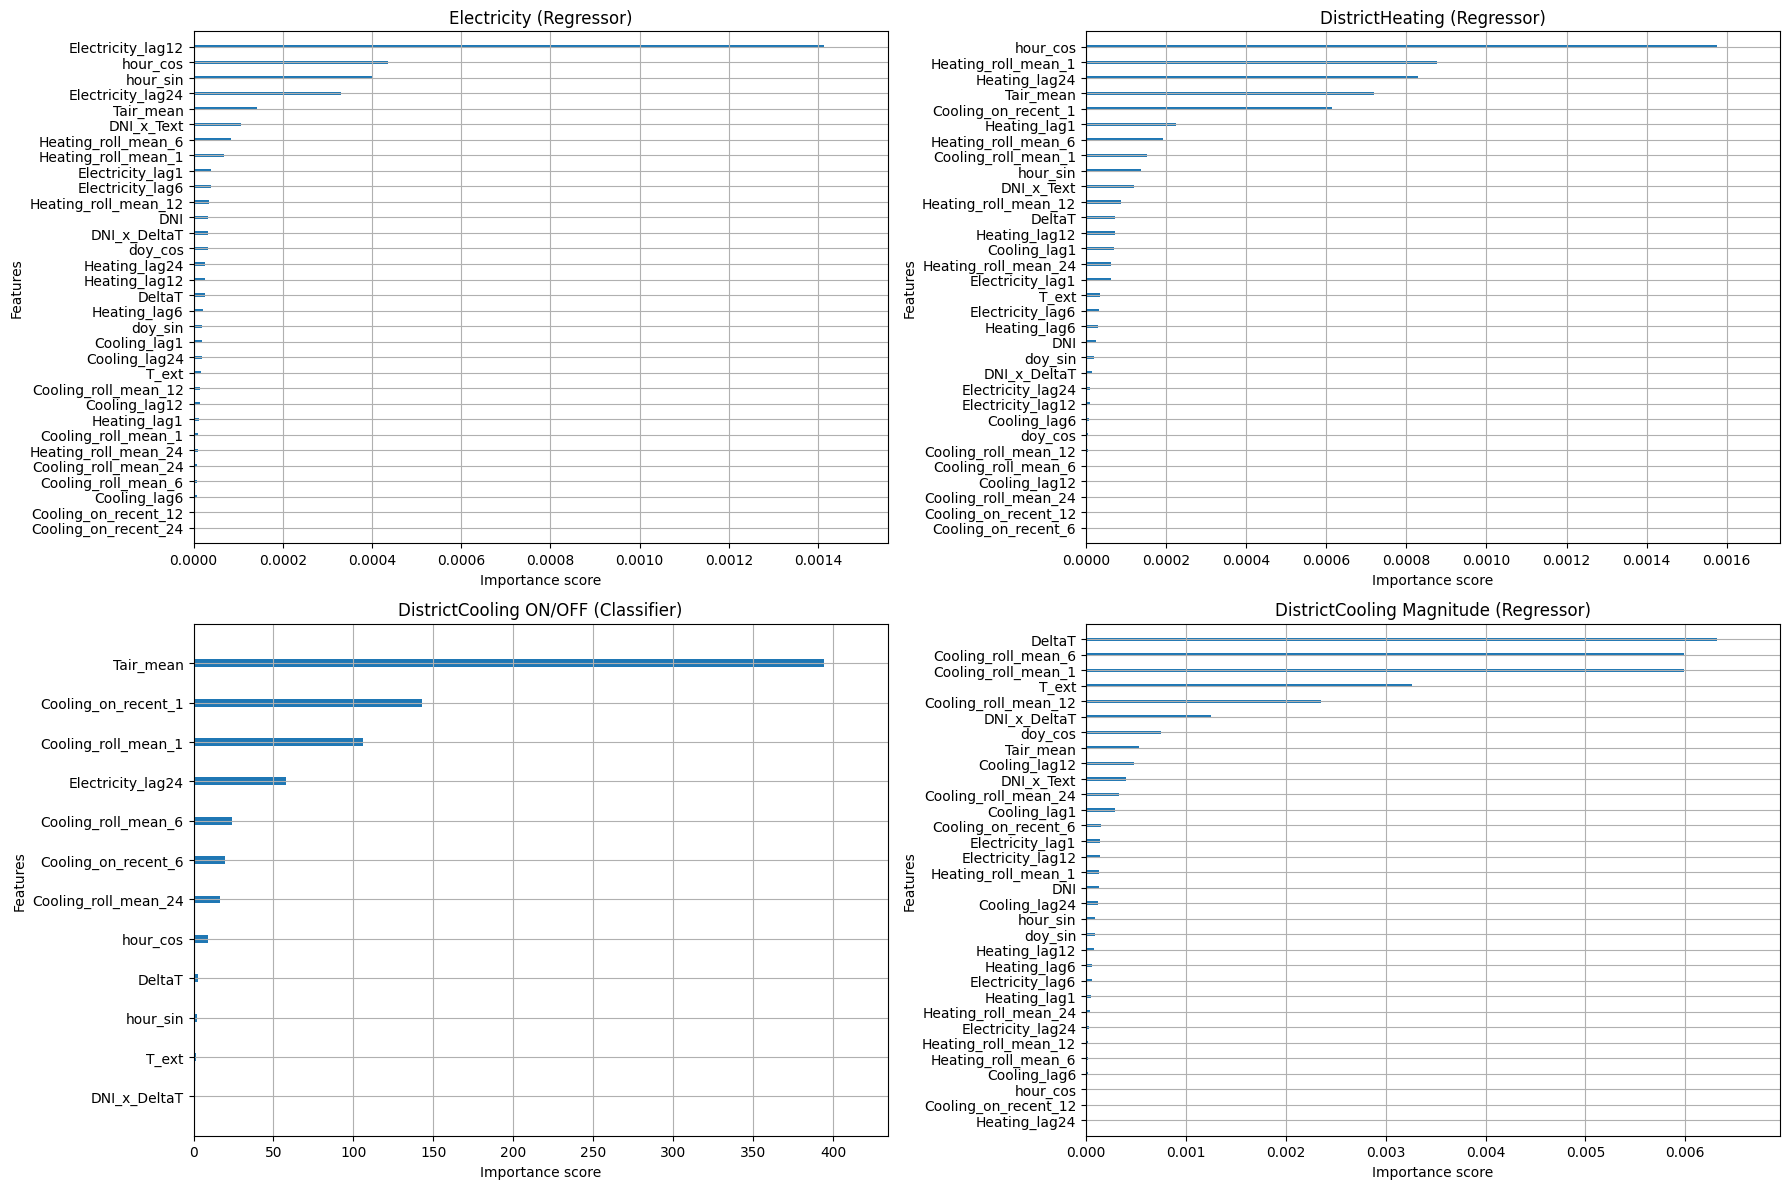


=== Feature Importance Analysis ===

Feature importance across all models:
                      Electricity  DistrictHeating  Cooling Classifier  \
Tair_mean                0.000143         0.000720          394.511658   
Cooling_on_recent_1      0.000000         0.000613          142.559952   
Cooling_roll_mean_1      0.000011         0.000153          105.814804   
Electricity_lag24        0.000330         0.000011           57.600037   
Cooling_roll_mean_6      0.000008         0.000003           23.942211   
Cooling_on_recent_6      0.000000         0.000001           19.826689   
Cooling_roll_mean_24     0.000008         0.000002           16.432230   
hour_cos                 0.000437         0.001576            9.180401   
DeltaT                   0.000025         0.000073            2.883545   
hour_sin                 0.000400         0.000136            2.363830   
T_ext                    0.000018         0.000035            1.365029   
DNI_x_DeltaT             0.000032   

In [87]:
# Visualize feature importance
model.plot_feature_importance()

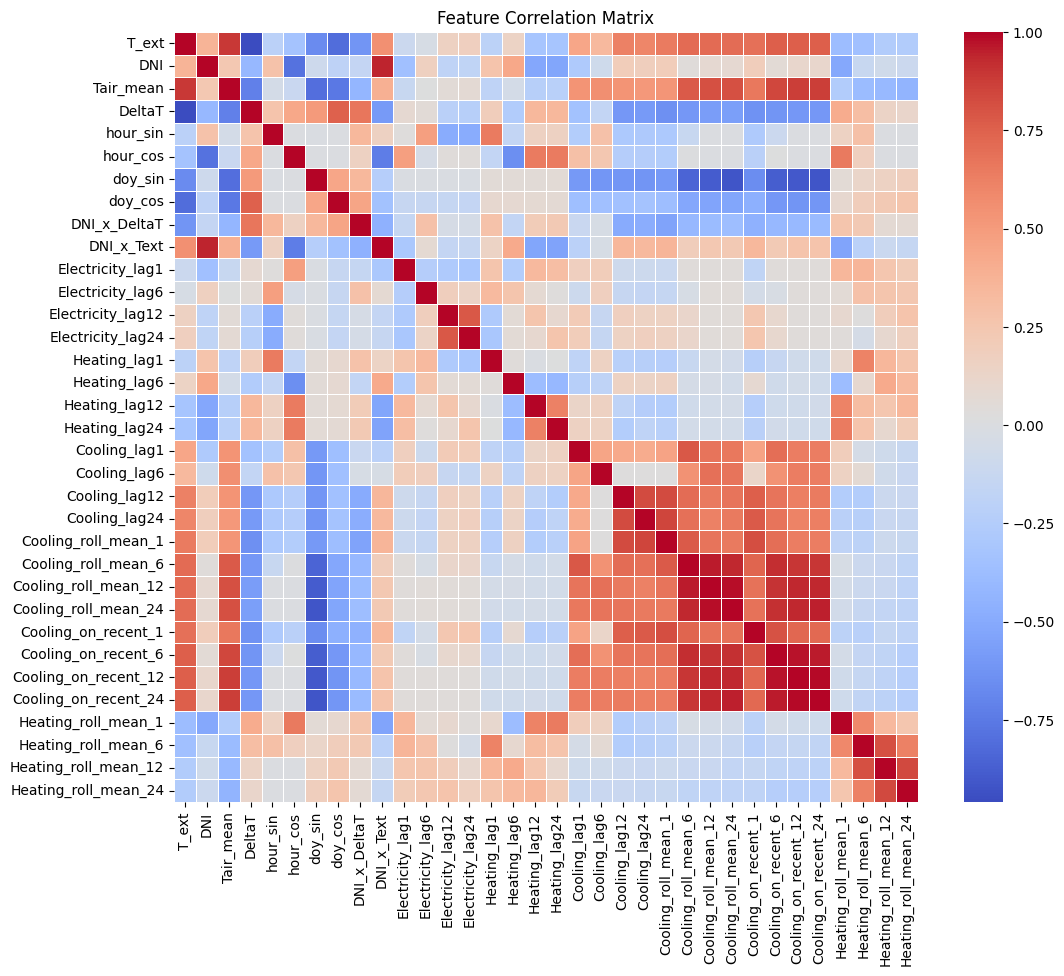

In [88]:
# plot correlation matrix of features
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(model.X_train.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

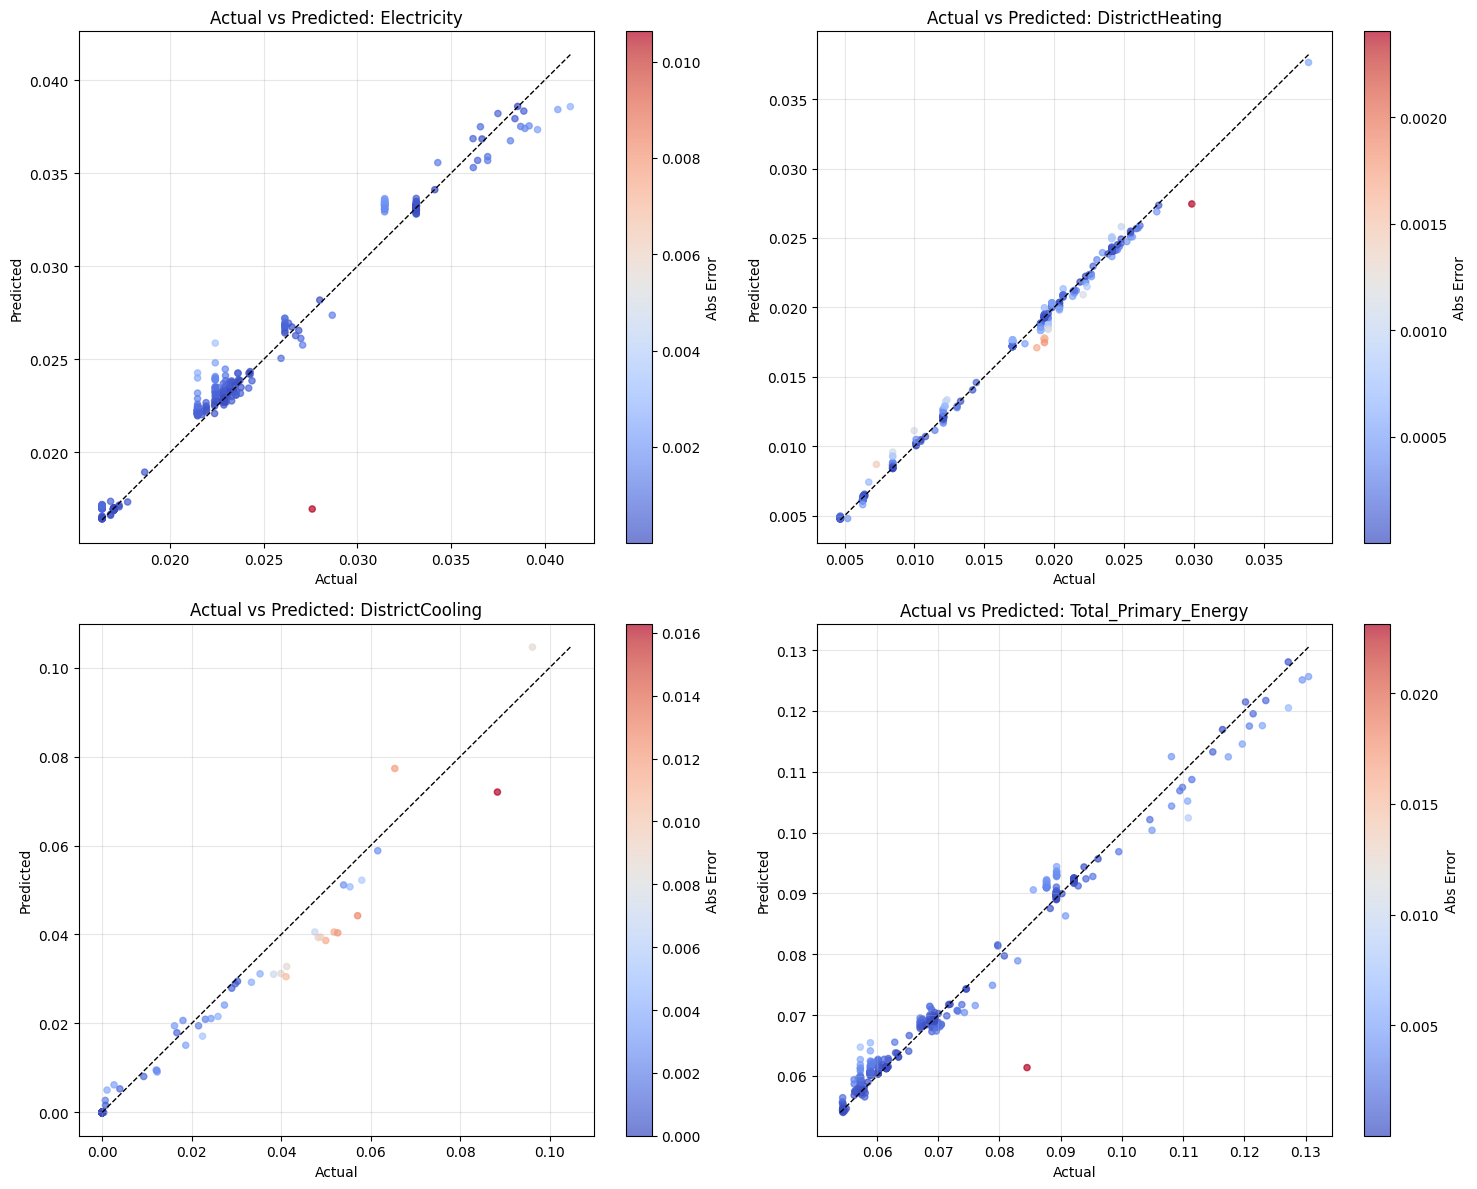

In [89]:
# Plot predicted vs actual scatter plots
model.plot_scatter_error()

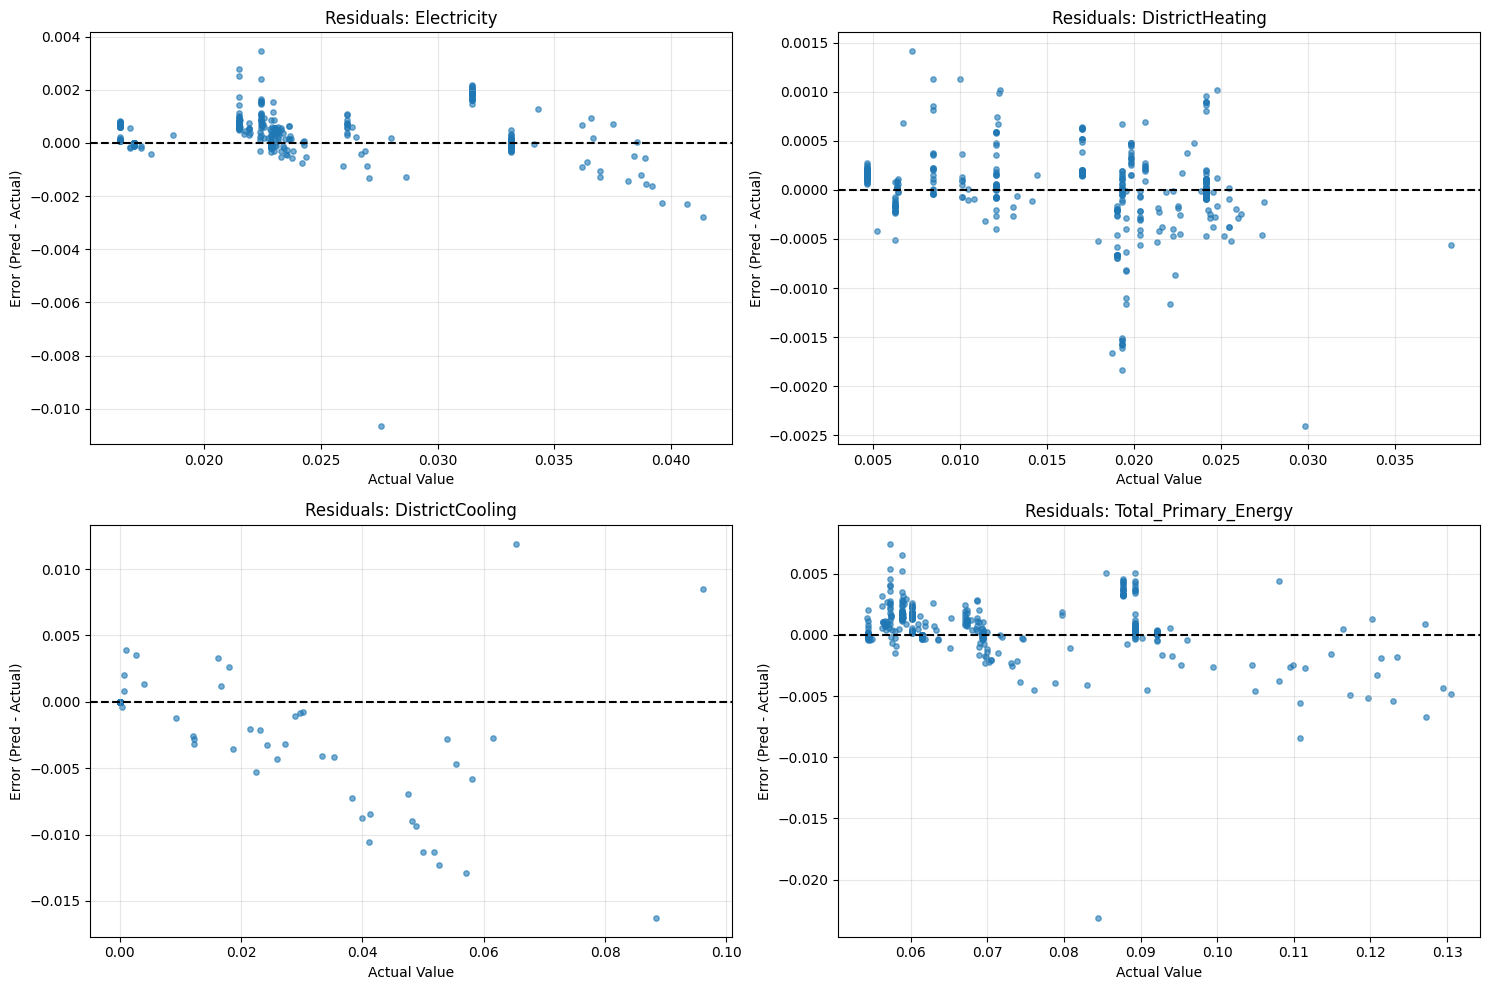

In [90]:
# Plot residual errors
model.plot_error_vs_actual()

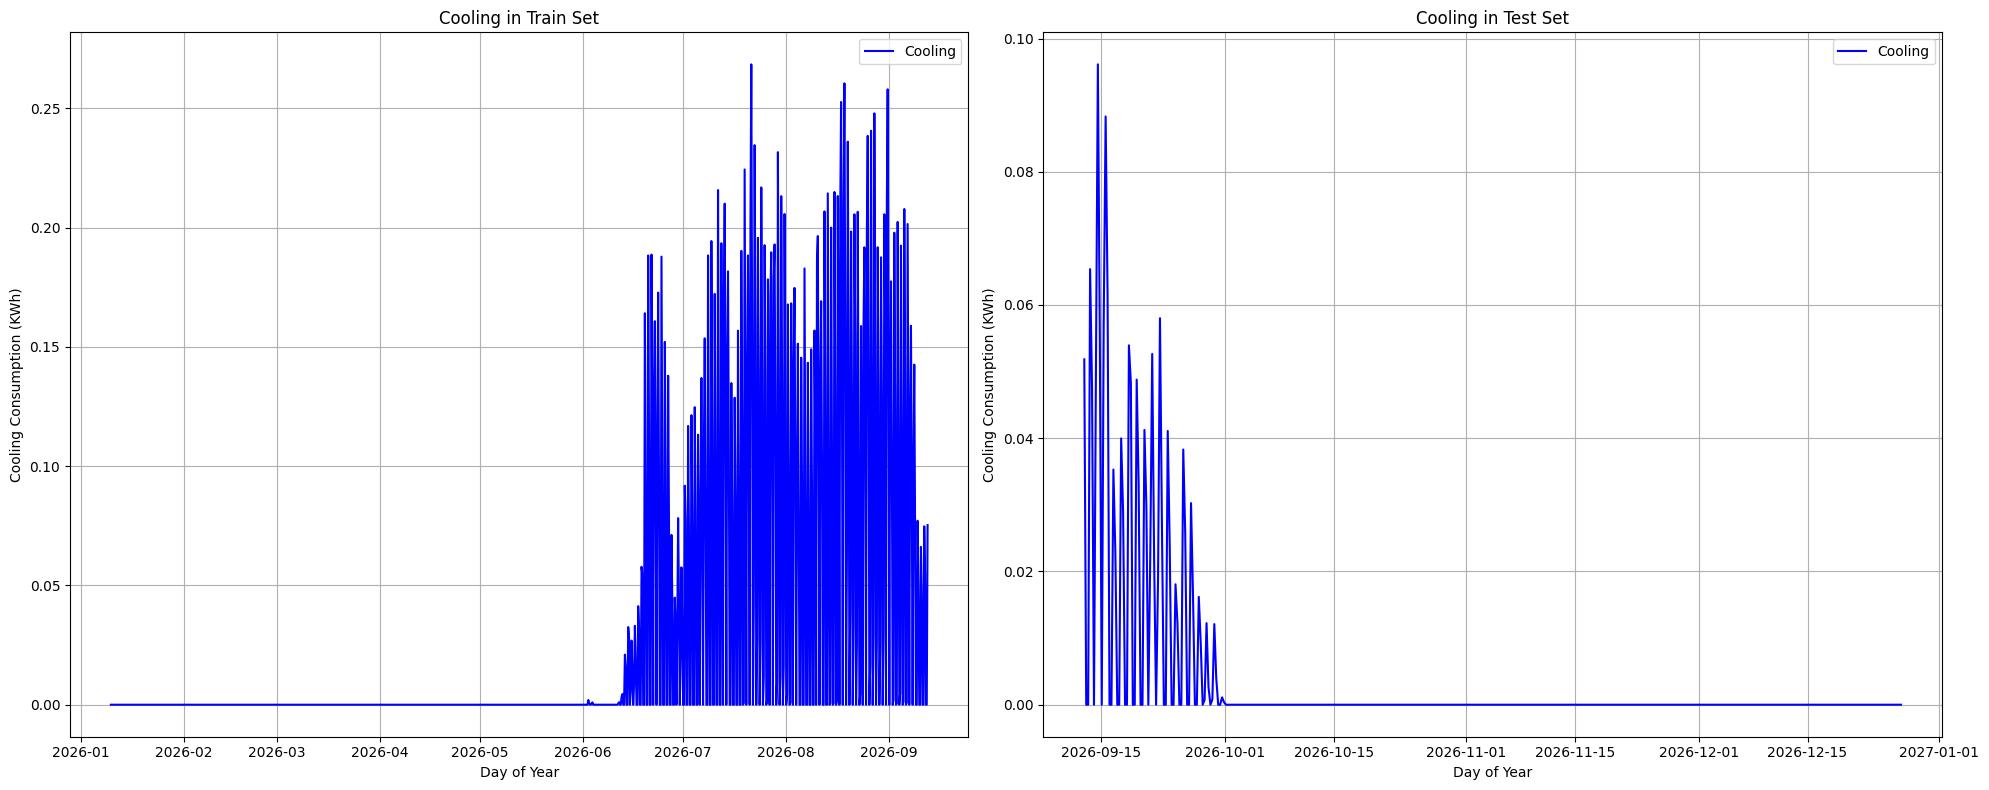

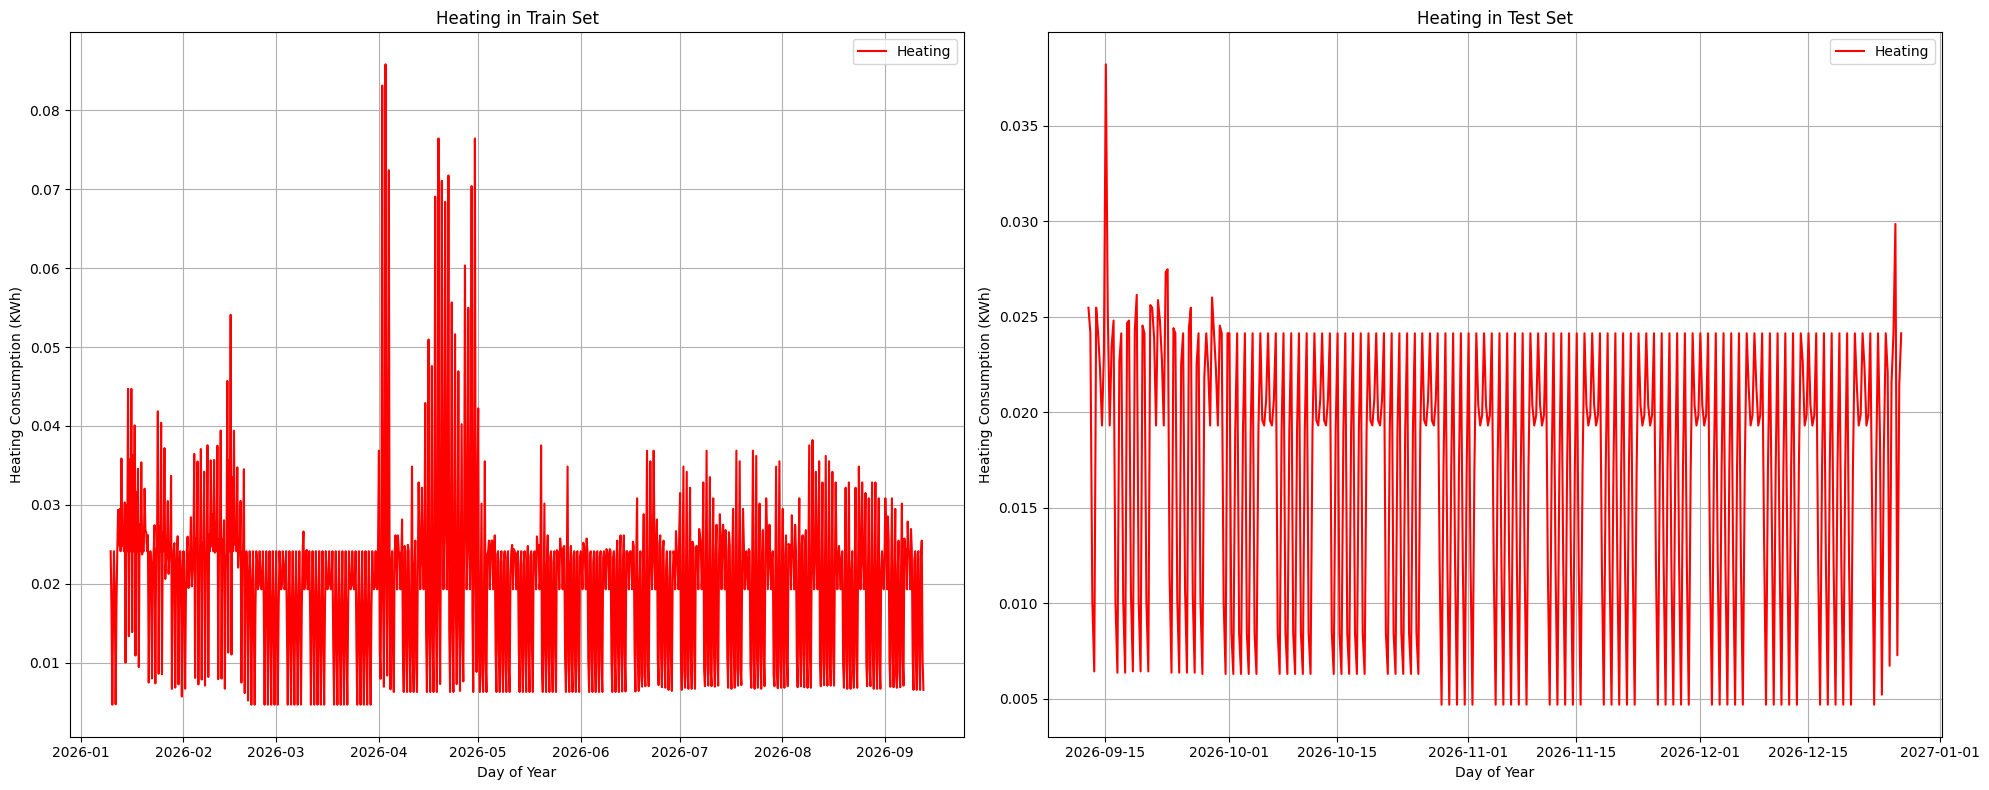

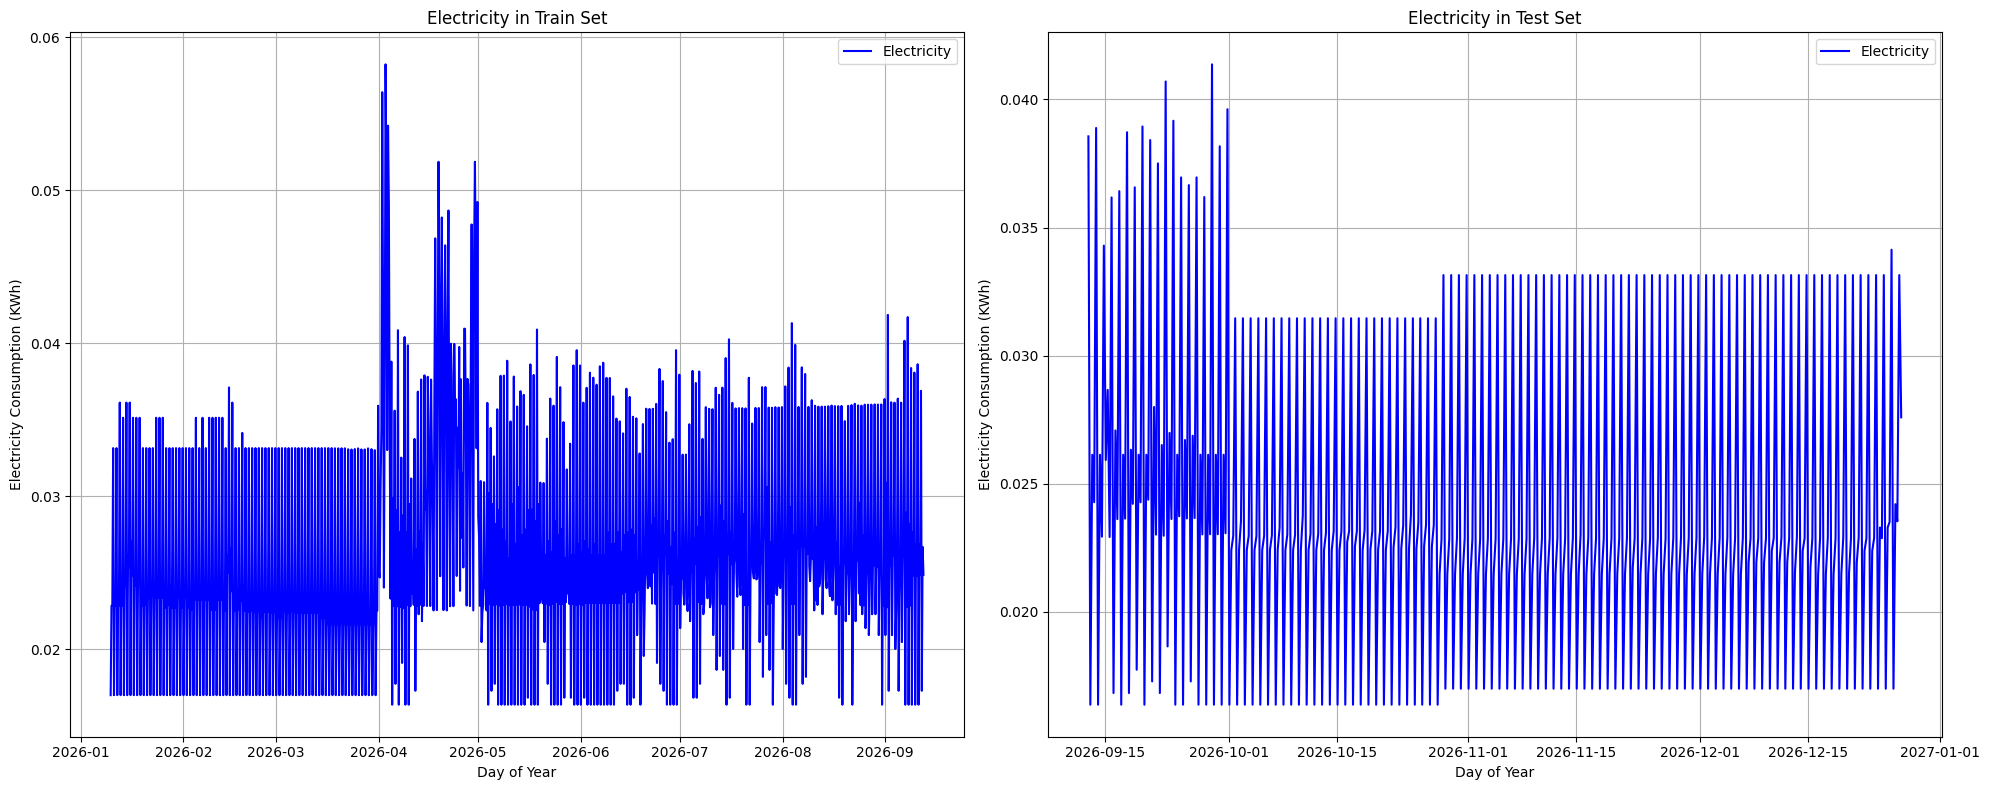

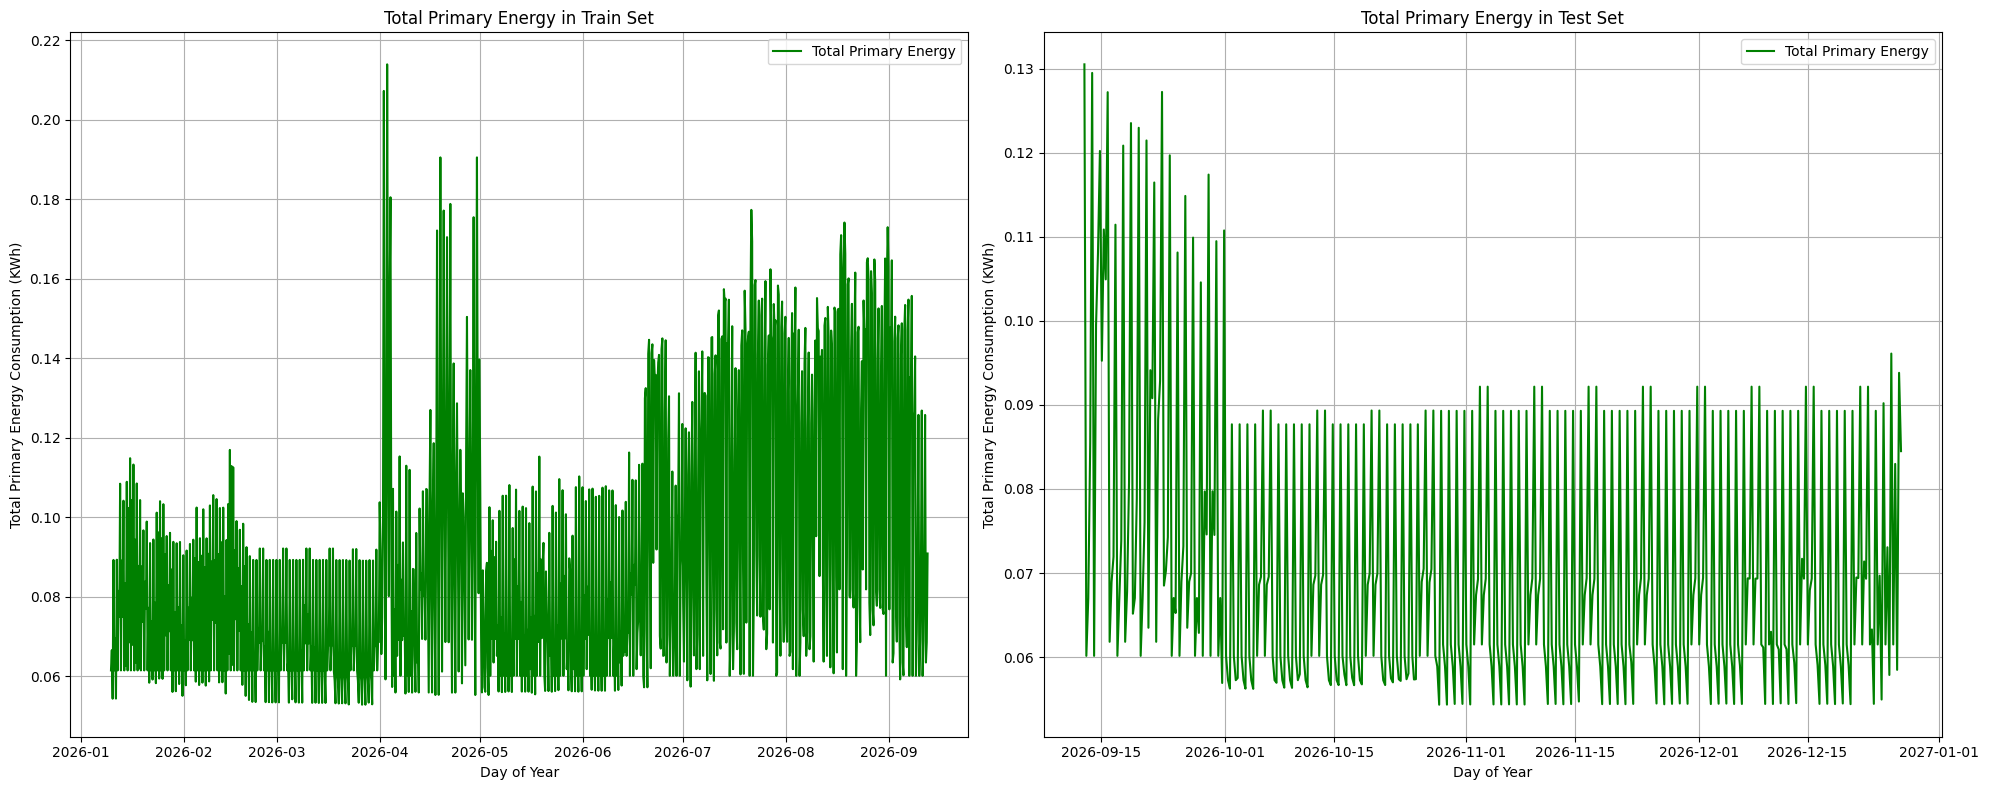

In [101]:
# read csv files
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

# show trend of cooling consumption in train/test set
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].plot(model.timesteps_train, y_train['DistrictCooling'].values, label='Cooling', color='blue')
axes[0].set_title('Cooling in Train Set')
axes[0].set_xlabel('Day of Year')
axes[0].set_ylabel('Cooling Consumption (KWh)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(model.timesteps_test, y_test['DistrictCooling'].values, label='Cooling', color='blue')
axes[1].set_title('Cooling in Test Set')
axes[1].set_xlabel('Day of Year')
axes[1].set_ylabel('Cooling Consumption (KWh)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# show trend of heating consumption in train/test set
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].plot(model.timesteps_train, y_train['DistrictHeating'].values, label='Heating', color='red')
axes[0].set_title('Heating in Train Set')
axes[0].set_xlabel('Day of Year')
axes[0].set_ylabel('Heating Consumption (KWh)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(model.timesteps_test, y_test['DistrictHeating'].values, label='Heating', color='red')
axes[1].set_title('Heating in Test Set')
axes[1].set_xlabel('Day of Year')
axes[1].set_ylabel('Heating Consumption (KWh)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# show trend of electrical consumption in train/test set
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].plot(model.timesteps_train, y_train['Electricity'].values, label='Electricity', color='blue')
axes[0].set_title('Electricity in Train Set')
axes[0].set_xlabel('Day of Year')
axes[0].set_ylabel('Electricity Consumption (KWh)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(model.timesteps_test, y_test['Electricity'].values, label='Electricity', color='blue')
axes[1].set_title('Electricity in Test Set')
axes[1].set_xlabel('Day of Year')
axes[1].set_ylabel('Electricity Consumption (KWh)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# show trend of total energy consumption in train/test set
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].plot(model.timesteps_train, model.compute_total_primary_energy(y_train)['Total_Primary_Energy'].values, label='Total Primary Energy', color='green')
axes[0].set_title('Total Primary Energy in Train Set')
axes[0].set_xlabel('Day of Year')
axes[0].set_ylabel('Total Primary Energy Consumption (KWh)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(model.timesteps_test, model.compute_total_primary_energy(y_test)['Total_Primary_Energy'].values, label='Total Primary Energy', color='green')
axes[1].set_title('Total Primary Energy in Test Set')
axes[1].set_xlabel('Day of Year')
axes[1].set_ylabel('Total Primary Energy Consumption (KWh)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [102]:
on_cooling = (y_train['DistrictCooling'] > model.cooling_threshold).sum() + (y_test['DistrictCooling'] > model.cooling_threshold).sum()
num_samples = len(y_train) + len(y_test)
print(f"Cooling ON samples: {on_cooling} / {num_samples} ({100.0 * on_cooling / num_samples:.2f}%)")

on_heating = (y_train['DistrictHeating'] > model.cooling_threshold).sum() + (y_test['DistrictHeating'] > model.cooling_threshold).sum()
num_samples = len(y_train) + len(y_test)
print(f"Heating ON samples: {on_heating} / {num_samples} ({100.0 * on_heating / num_samples:.2f}%)")

Cooling ON samples: 289 / 1405 (20.57%)
Heating ON samples: 1405 / 1405 (100.00%)
